# 03 — Residual Extraction and Diagnostics

## Purpose
This notebook extracts forecast residuals from fitted models and evaluates their statistical properties.

## Outputs
- Residual datasets
- Distribution diagnostics
- QQ plots and histograms
- Residual autocorrelation diagnostics

## Future Work
- Add multivariate dependence diagnostics
- Investigate residual heteroskedasticity measures

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd

from src.utils.seeds import set_seed
from src.utils.device import get_device

from src.experiments.config import ExperimentConfig
from src.experiments.paths import result_dirs
from src.experiments.artifacts import (
    load_array_npz,
    save_array_npz,
    save_table,
    save_json,
    save_current_figure,
)

from src.api.modeling import extract_residuals

set_seed(123)

config = ExperimentConfig()
dgp_names = config.dgp_names

lags = config.lags
n_train = config.n_train
n_test = 100

rnn_context_length = 40
rnn_prediction_length = 40
rnn_hidden_dim = 64
rnn_num_layers = 1
rnn_dropout = 0.0
rnn_batch_size = 32
rnn_epochs = 100
rnn_lr = 1e-3
rnn_device = get_device()

dirs = result_dirs(
    "03_residuals",
    test=False,
)

simulated_dir = ROOT / "data" / "simulated"

datasets = {}

for name in dgp_names:
    path = simulated_dir / f"{name}_var_dgp.npz"
    data = load_array_npz(path)

    y = data["y"]

    datasets[name] = {
        "y": y,
        "y_train": y[:n_train],
        "y_test": y[n_train:n_train + n_test],
        "innovations": data["innovations"],
        "A": data["A"],
        "Sigma": data["Sigma"],
    }

    print(
        name,
        datasets[name]["y_train"].shape,
        datasets[name]["y_test"].shape,
    )

gaussian (600, 3) (100, 3)
student_t (600, 3) (100, 3)
mixture (600, 3) (100, 3)
heteroskedastic (600, 3) (100, 3)


In [2]:
from src.api.residuals import extract_forecast_residuals

residual_store = extract_forecast_residuals(
    datasets=datasets,
    lags=lags,
    rnn_context_length=rnn_context_length,
    rnn_prediction_length=rnn_prediction_length,
    rnn_hidden_dim=rnn_hidden_dim,
    rnn_num_layers=rnn_num_layers,
    rnn_dropout=rnn_dropout,
    rnn_batch_size=rnn_batch_size,
    rnn_epochs=rnn_epochs,
    rnn_lr=rnn_lr,
    rnn_device=rnn_device,
)

var_residual_store = residual_store["VAR"]
rnn_residual_store = residual_store["RNN"]

/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/vector_ar/fit.py:63: RuntimeWarning: divide by zero encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/vector_ar/fit.py:63: RuntimeWarning: overflow encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/vector_ar/fit.py:63: RuntimeWarning: invalid value encountered in matmul
  fitted = X @ beta


gaussian VAR: (599, 3) RNN: (560, 3)


/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/vector_ar/fit.py:63: RuntimeWarning: divide by zero encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/vector_ar/fit.py:63: RuntimeWarning: overflow encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/vector_ar/fit.py:63: RuntimeWarning: invalid value encountered in matmul
  fitted = X @ beta


student_t VAR: (599, 3) RNN: (560, 3)
mixture VAR: (599, 3) RNN: (560, 3)
heteroskedastic VAR: (599, 3) RNN: (560, 3)


In [3]:
for name in dgp_names:

    save_array_npz(
        dirs["residuals"] / f"{name}_var_residuals.npz",
        residuals=var_residual_store[name],
    )

    save_array_npz(
        dirs["residuals"] / f"{name}_rnn_residuals.npz",
        residuals=rnn_residual_store[name],
    )

print(
    "Saved residual files:",
    dirs["residuals"]
)

Saved residual files: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/residuals/03_residuals


In [4]:
from src.api.residuals import residual_diagnostics_table

residual_diagnostics_df = residual_diagnostics_table(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
)

save_table(
    residual_diagnostics_df,
    dirs["tables"] / "residual_diagnostics.csv",
)

residual_diagnostics_df

,dgp,forecast_model,series,n_residuals,mean,std,skewness,kurtosis,excess_kurtosis,jb_stat,jb_pvalue
0,gaussian,VAR,1,599,1.422531e-16,1.010717,-0.075714,3.253305,0.253305,2.021393,3.639653e-01
1,gaussian,VAR,2,599,-4.170287e-17,0.996334,0.247366,3.271039,0.271039,7.749630,2.075818e-02
2,gaussian,VAR,3,599,-1.595830e-16,1.039456,0.004211,3.021352,0.021352,0.004878,9.975638e-01
3,student_t,VAR,1,599,-1.992470e-16,1.439405,0.690427,8.446322,5.446322,772.703382,1.620289e-168
4,student_t,VAR,2,599,-8.525920e-18,1.399507,-0.686971,7.872340,4.872340,627.145047,6.564223e-137
5,student_t,VAR,3,599,5.152621e-17,1.433355,-0.547394,9.702939,6.702939,1129.212373,6.232305e-246
6,mixture,VAR,1,599,-1.360440e-16,1.452208,0.680663,9.650716,6.650716,1128.378877,9.454533e-246
7,mixture,VAR,2,599,1.779322e-17,1.409137,-0.375269,9.060935,6.060935,912.626966,6.692251e-199
8,mixture,VAR,3,599,-1.075007e-17,1.462368,-0.340925,6.980858,3.980858,398.537812,2.874841e-87
9,heteroskedastic,VAR,1,599,-8.525920e-18,1.866628,-0.098709,5.851735,2.851735,199.163184,5.652807e-44


In [5]:
from src.api.residuals import residual_diagnostics_summary

summary_df = residual_diagnostics_summary(
    residual_diagnostics_df,
)

save_table(
    summary_df,
    dirs["tables"] / "residual_diagnostics_summary.csv",
)

summary_df

,dgp,forecast_model,mean,std,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,gaussian,RNN,-1.280691e-02,0.941256,-0.032683,3.588507,0.588507,1.069206e-01
1,gaussian,VAR,-1.967758e-17,1.015502,0.058621,3.181899,0.181899,4.607624e-01
2,heteroskedastic,RNN,-1.683607e-02,1.849100,-0.243038,5.702470,2.702470,3.501456e-32
3,heteroskedastic,VAR,-4.151752e-17,1.828823,-0.165010,5.701282,2.701282,2.778164e-38
4,mixture,RNN,-9.765846e-04,1.427922,-0.091890,8.344716,5.344716,1.012133e-98
5,mixture,VAR,-4.300029e-17,1.441238,-0.011844,8.564170,5.564170,9.582803e-88
6,student_t,RNN,1.816943e-03,1.394377,-0.267775,8.974455,5.974455,6.932850e-63
7,student_t,VAR,-5.208225e-17,1.424089,-0.181313,8.673867,5.673867,2.188074e-137


Saved: var_rnn_residual_histograms.png


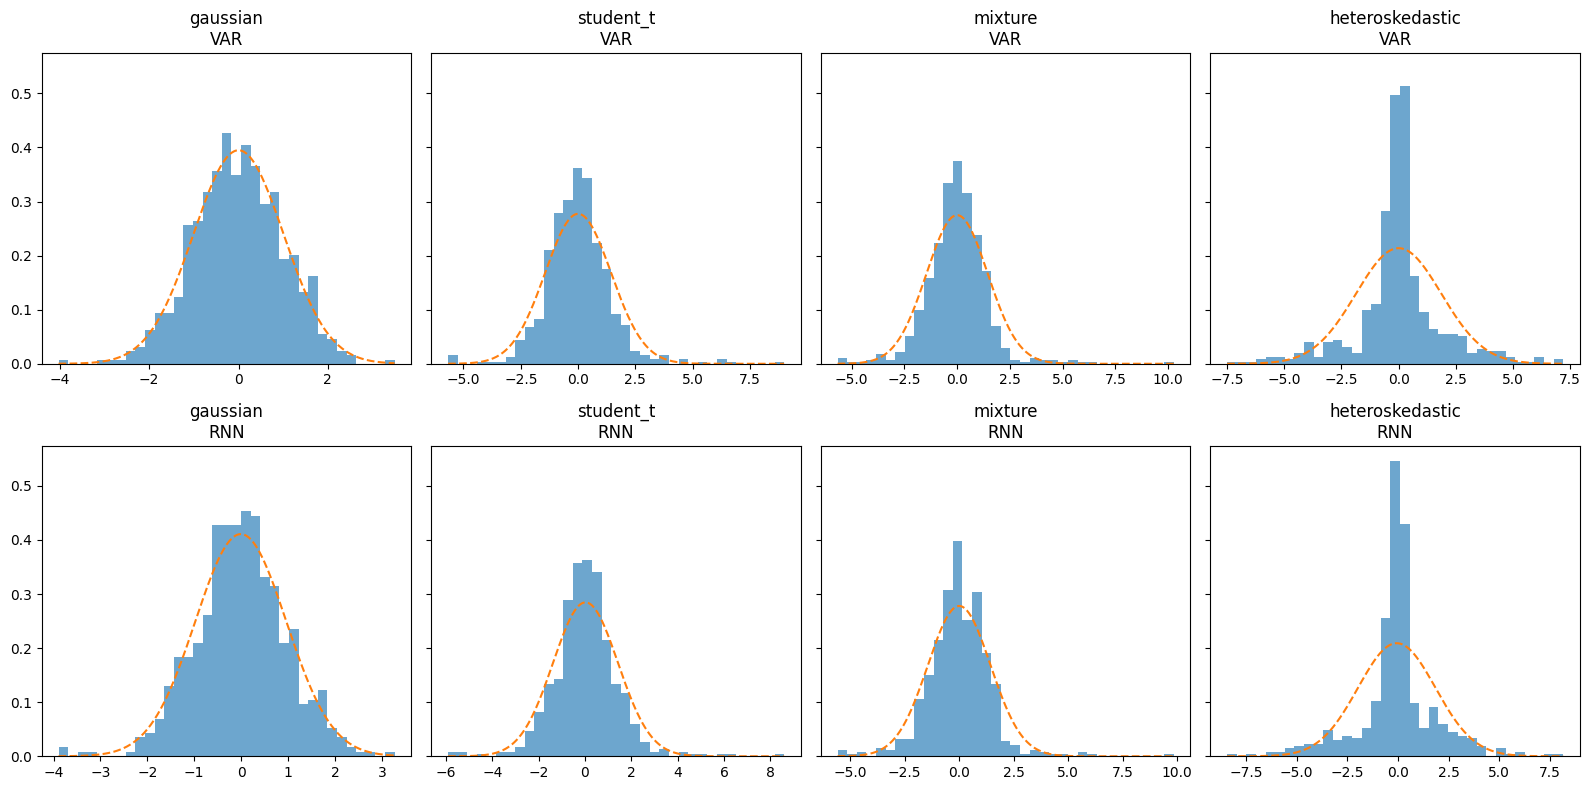

In [6]:
from src.plots.residuals import plot_residual_histograms

plot_residual_histograms(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
    dgp_names=dgp_names,
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "var_rnn_residual_histograms.png"
)

print(
    "Saved: var_rnn_residual_histograms.png"
)

Saved: var_rnn_residual_qqplots.png


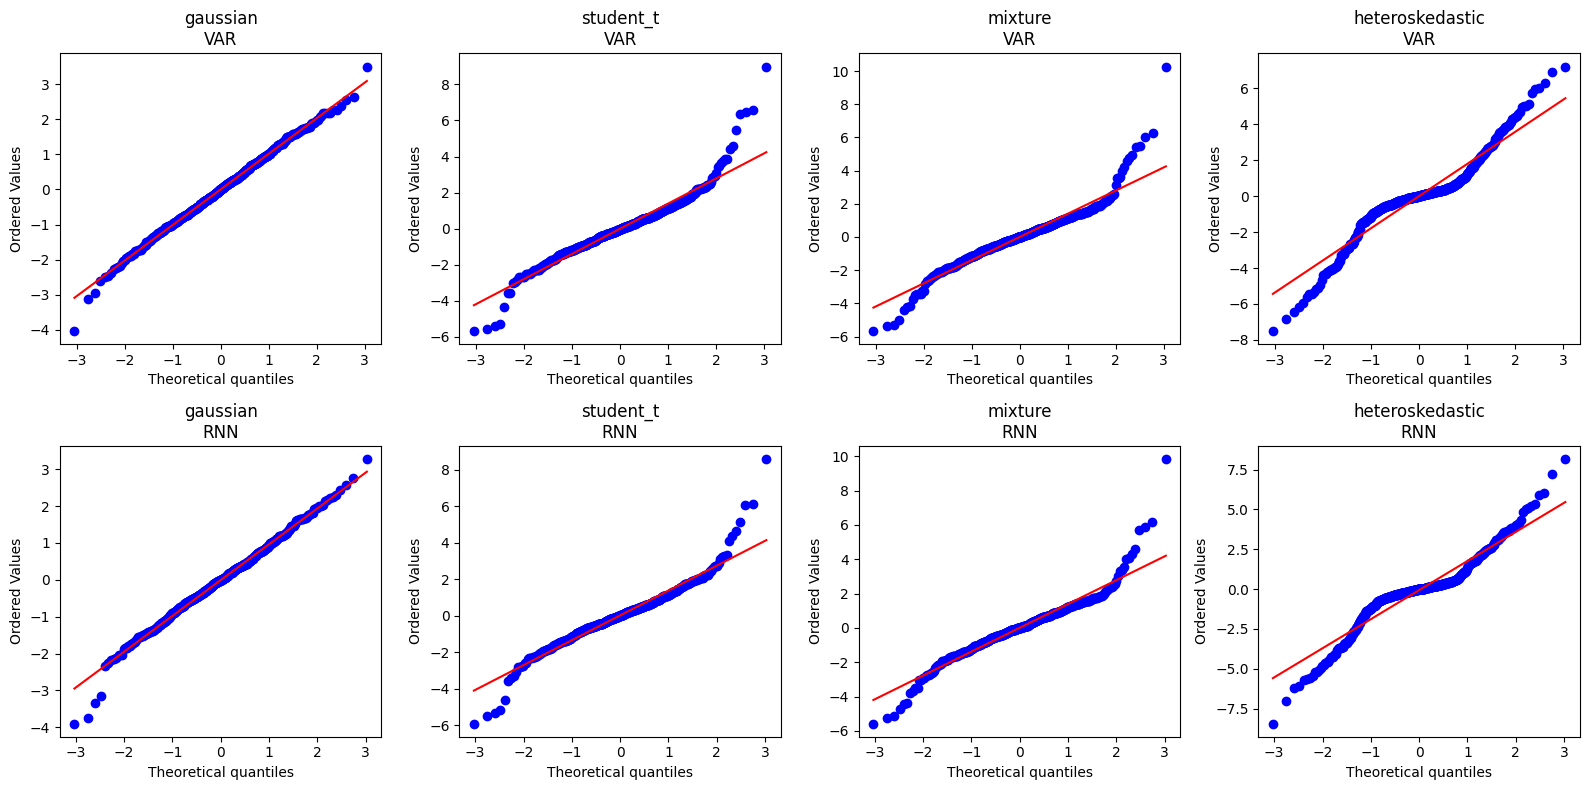

In [7]:
from src.plots.residuals import plot_residual_qqplots

plot_residual_qqplots(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
    dgp_names=dgp_names,
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "var_rnn_residual_qqplots.png"
)

print(
    "Saved: var_rnn_residual_qqplots.png"
)

Saved: var_rnn_residual_acf.png


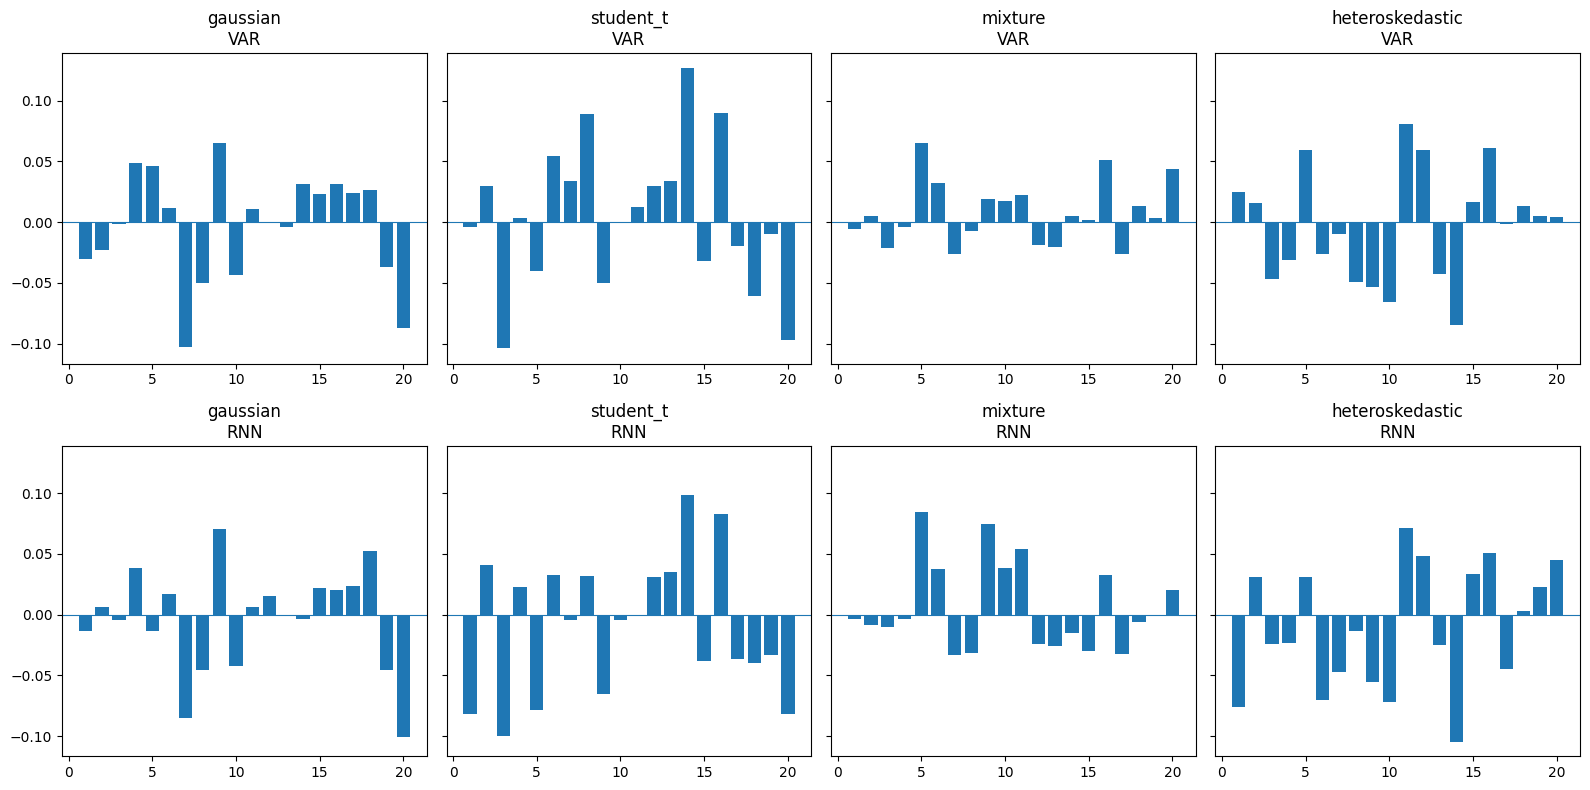

In [8]:
from src.plots.residuals import plot_residual_acf

plot_residual_acf(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
    dgp_names=dgp_names,
    variable=0,
    max_lag=20,
)

save_current_figure(
    dirs["figures"]
    / "var_rnn_residual_acf.png"
)

print(
    "Saved: var_rnn_residual_acf.png"
)

In [9]:
from src.api.residuals import residual_acf_summary

acf_df = residual_acf_summary(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
)

save_table(
    acf_df,
    dirs["tables"] / "residual_acf_summary.csv",
)

acf_df

,dgp,forecast_model,acf_lag1,acf_lag5
0,gaussian,VAR,-0.030163,0.046653
1,student_t,VAR,-0.004299,-0.039743
2,mixture,VAR,-0.005535,0.064950
3,heteroskedastic,VAR,0.024777,0.059241
4,gaussian,RNN,-0.013627,-0.013020
5,student_t,RNN,-0.081589,-0.078475
6,mixture,RNN,-0.003169,0.084157
7,heteroskedastic,RNN,-0.076238,0.031157


Saved: var_rnn_rolling_residual_std.png


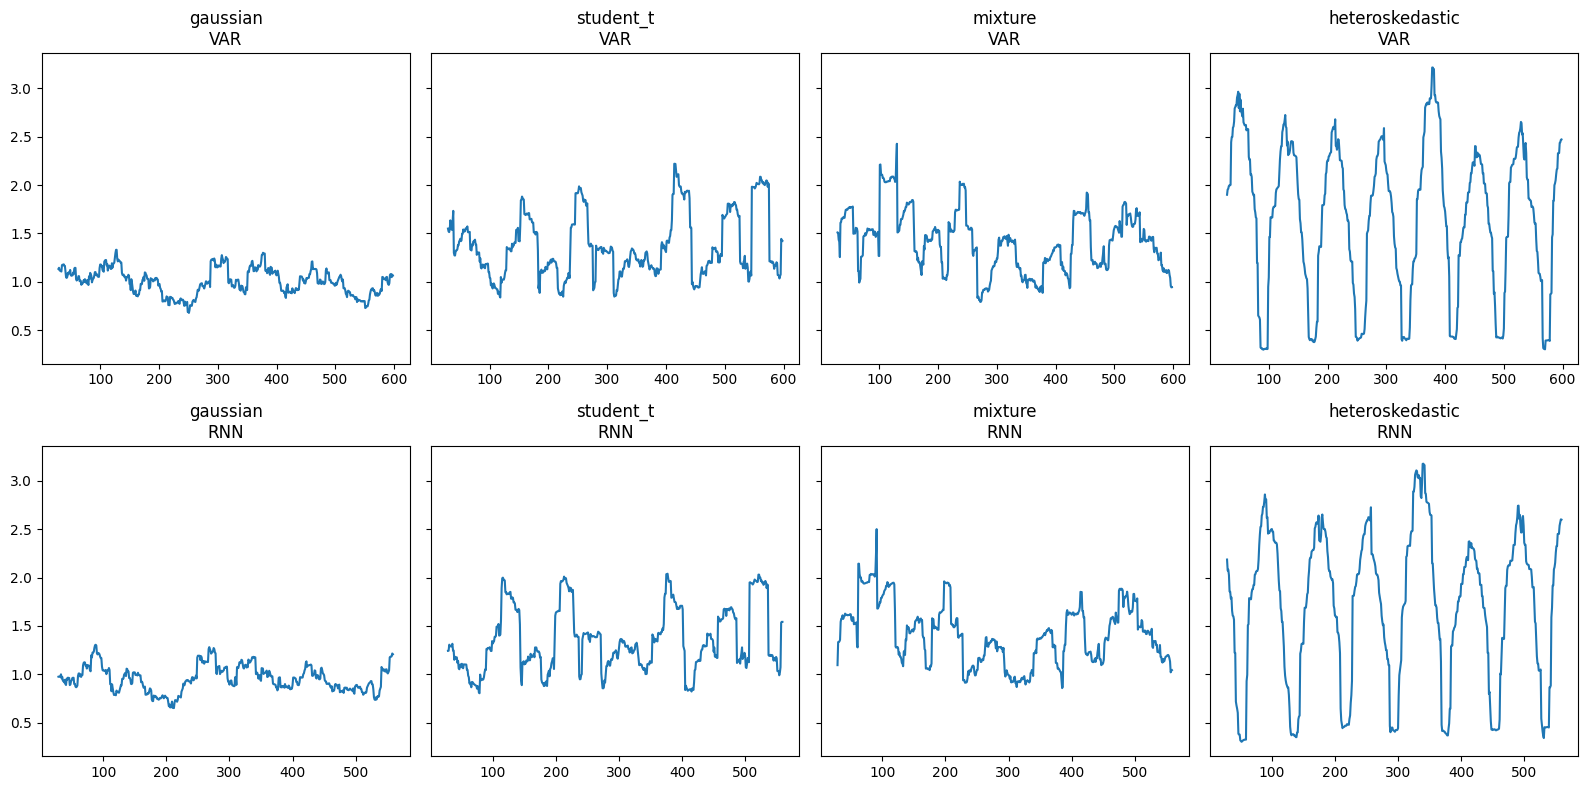

In [10]:
from src.plots.residuals import plot_rolling_residual_std

window = 30

plot_rolling_residual_std(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
    dgp_names=dgp_names,
    variable=0,
    window=window,
)

save_current_figure(
    dirs["figures"]
    / "var_rnn_rolling_residual_std.png"
)

print(
    "Saved: var_rnn_rolling_residual_std.png"
)

In [11]:
from src.api.residuals import rolling_variance_summary

variance_df = rolling_variance_summary(
    var_residual_store=var_residual_store,
    rnn_residual_store=rnn_residual_store,
    window=window,
)

save_table(
    variance_df,
    dirs["tables"]
    / "rolling_variance_summary.csv",
)

variance_df

,dgp,forecast_model,mean_rolling_std,std_rolling_std,cv_rolling_std
0,gaussian,VAR,1.001892,0.134361,0.134107
1,student_t,VAR,1.377472,0.329566,0.239254
2,mixture,VAR,1.423077,0.310879,0.218456
3,heteroskedastic,VAR,1.679558,0.789779,0.470230
4,gaussian,RNN,0.955102,0.135124,0.141476
5,student_t,RNN,1.356665,0.328570,0.242190
6,mixture,RNN,1.417417,0.311440,0.219723
7,heteroskedastic,RNN,1.689654,0.795737,0.470947


In [12]:
save_json(
    {
        "notebook": "03_residuals",
        "forecast_models": [
            "VAR",
            "RNN",
        ],
        "dgp_names": dgp_names,
        "n_train": n_train,
        "lags": lags,
        "rnn_context_length": rnn_context_length,
        "rnn_prediction_length": rnn_prediction_length,
        "residual_diagnostics_saved": True,
        "histograms_saved": True,
        "qqplots_saved": True,
        "acf_plots_saved": True,
        "rolling_variance_plots_saved": True,
    },
    dirs["logs"] / "residual_metadata.json",
)

print(
    "03_residuals completed."
)

03_residuals completed.
